# Emotion Classification from Text — Machine Learning Assignment

## Student Details
- **Name:** עידו ע
- **ID (last 4 digits):** 9083

## Problem Description
This assignment addresses a **multi-class text classification** problem: given a short
English sentence describing a personal experience, predict the emotion it expresses.

The dataset contains 20,000 English sentences labeled with one of six emotions: *joy*,
*sadness*, *anger*, *fear*, *love*, and *surprise*. It arrives pre-split into 16,000
training examples, 2,000 test examples and 2,000 validation examples. After removing 11
training sentences that also appeared in the test set (see the data leakage check below),
15,989 training examples remain.

The dataset is notably **imbalanced** — the largest class (*joy*, 5,362 examples) is
roughly 9.4 times larger than the smallest (*surprise*, 572 examples). This imbalance
drives several decisions made later in this notebook.

**Learning type:** Supervised classification
**Algorithm:** Multinomial Naive Bayes (implemented from scratch)
**Evaluation metric:** Macro-averaged F1

**Dataset:** https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp

## AI Assistance
See the dedicated cell below documenting all AI chatbot usage.

## AI Assistance — Prompts and Usage

This section documents all use of AI chatbots during this assignment, as required.

**Tool used:** Claude (Anthropic)

| # | Purpose | Prompt / Question | How the output was used |
|---|---------|-------------------|-------------------------|
| 1 | Choosing an algorithm | Asked whether Naive Bayes is a suitable algorithm for this dataset and assignment requirements | Confirmed the choice; guided the decision to use macro-F1 and to treat class imbalance as an extension |
| 2 | Data loading | Asked how to load a semicolon-separated text file without a header row into pandas | Learned about the `sep`, `names` and `header` parameters of `read_csv` |
| 3 | Data validation | Asked what sanity checks should be run on a text dataset before modeling | Added checks for missing values, duplicate rows, and train/test overlap |
| 4 | Model comparison | Asked how to benchmark the from-scratch Naive Bayes against library models (SVM, KNN, Decision Tree) without excessive runtime | Learned to use `LinearSVC` rather than `SVC` for high-dimensional text, and to run comparisons once on the winning configuration rather than inside the grid search |
| 5 | Naive Bayes implementation | Wrote a dictionary-based implementation first and asked for a review; asked how to expose `alpha` and `fit_prior` as tunable parameters and how to express the computation with matrices | Learned to represent class-conditional counts as an (n_classes × n_features) matrix and prediction as a single matrix product, and to validate the result against `MultinomialNB` by comparing learned parameters rather than only scores |

*(Rows will be added as work progresses.)*

---
# Part 1 — Data Loading and Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', 200)


def load_data(file_path):
    """Load a semicolon-separated emotion dataset file into a DataFrame."""
    return pd.read_csv(file_path, sep=';', names=['text', 'label'], header=None)


def print_data_info(data, name):
    """Print shape, missing values, duplicates, class distribution and first rows."""
    print(f"--- {name} ---")
    print("Shape:", data.shape)

    print("\nMissing values per column:")
    print(data.isnull().sum())

    print("\nExact duplicate rows (text + label):", data.duplicated().sum())
    print("Duplicate texts (regardless of label):", data.duplicated(subset='text').sum())

    print("\nClass distribution:")
    print(data['label'].value_counts())

    print("\nFirst 5 rows:")
    display(data.head())
    print()


train = load_data('data/train.txt')
test = load_data('data/test.txt')
val = load_data('data/val.txt')

print_data_info(train, "Train")
print_data_info(test, "Test")
print_data_info(val, "Validation")

--- Train ---
Shape: (16000, 2)

Missing values per column:
text     0
label    0
dtype: int64

Exact duplicate rows (text + label): 1
Duplicate texts (regardless of label): 31

Class distribution:
label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

First 5 rows:


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger



--- Test ---
Shape: (2000, 2)

Missing values per column:
text     0
label    0
dtype: int64

Exact duplicate rows (text + label): 0
Duplicate texts (regardless of label): 0

Class distribution:
label
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

First 5 rows:


,text,label
0,im feeling rather rotten so im not very ambitious right now,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy
4,i was feeling a little vain when i did this one,sadness



--- Validation ---
Shape: (2000, 2)

Missing values per column:
text     0
label    0
dtype: int64

Exact duplicate rows (text + label): 0
Duplicate texts (regardless of label): 2

Class distribution:
label
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64

First 5 rows:


,text,label
0,im feeling quite sad and sorry for myself but ill snap out of it soon,sadness
1,i feel like i am still looking at a blank canvas blank pieces of paper,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


### Data Quality Findings

**Missing values:** None in any split.

**Duplicates in the training set:** One exact duplicate row (identical text *and* label).
More interestingly, 31 texts appear more than once — meaning roughly 30 sentences carry
*conflicting labels* across their occurrences. The same sentence is annotated, for
example, as both *anger* and *sadness*.

These are annotation inconsistencies inherent to the dataset rather than errors in
loading. They set a small theoretical ceiling on achievable accuracy: no classifier can
be correct on both copies of a contradictory example.

**Decision: these rows are kept.** Removing both copies would discard genuine data, and
removing one copy would require arbitrarily deciding which label is correct. At roughly
0.2% of the training set the effect is negligible. The finding is documented here for
transparency.

**Test set:** Completely clean — no missing values and no duplicates of any kind. This
is important, since the test set is the basis for the final reported score.

### Checking for Overlap Between Splits

Before any modeling, we verify that no sentence appears in more than one split.
An example present in both the training and test sets would be seen by the model
during training and then used to evaluate it — a form of data leakage that inflates
the reported score.

In [2]:
train_texts = set(train['text'])
test_texts = set(test['text'])
val_texts = set(val['text'])

print("Overlap between train and test:", len(train_texts & test_texts))
print("Overlap between train and val: ", len(train_texts & val_texts))
print("Overlap between test and val:  ", len(test_texts & val_texts))

Overlap between train and test: 11
Overlap between train and val:  5
Overlap between test and val:   3


### Data Leakage Check

Eleven sentences appear in both the training set and the test set. If left in place,
the model would be evaluated on examples it had already seen during training, inflating
the reported score and misrepresenting how the model generalises to unseen data.

These eleven examples will be removed **from the training set** rather than from the test
set: the test set is the fixed benchmark against which final performance is reported and
must not be modified. The removal costs 0.07% of the training data, which is negligible.

The five sentences shared between train and validation, and the three shared between test
and validation, require no action — the validation file is not used anywhere in this
notebook, as 5-fold cross-validation on the training set serves that role instead.

In [3]:
overlap = train_texts & test_texts
print(f"Removing {len(overlap)} training examples that also appear in the test set.")
print("Train size before:", train.shape[0])

train = train[~train['text'].isin(overlap)].reset_index(drop=True)

print("Train size after: ", train.shape[0])
print("Overlap after removal:", len(set(train['text']) & test_texts))

Removing 11 training examples that also appear in the test set.
Train size before: 16000
Train size after:  15989
Overlap after removal: 0


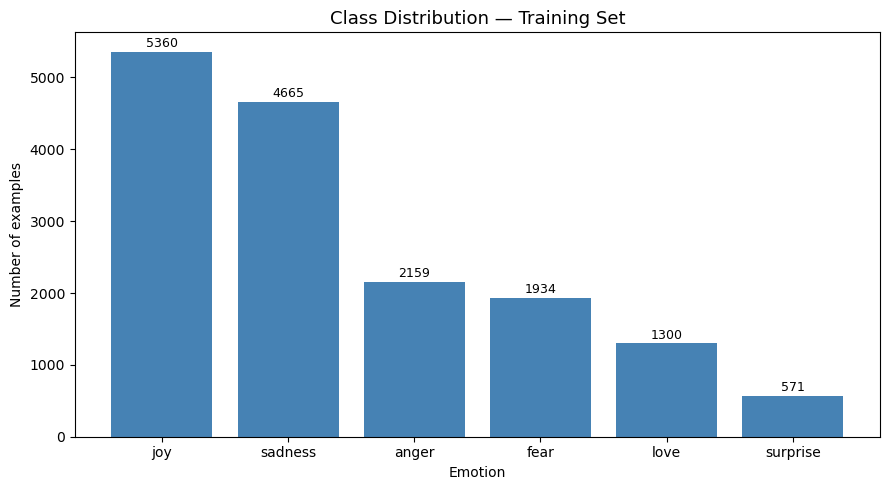

Imbalance ratio (largest / smallest): 9.4 : 1


In [4]:
counts = train['label'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color='steelblue')
plt.title('Class Distribution — Training Set', fontsize=13)
plt.xlabel('Emotion')
plt.ylabel('Number of examples')

for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 60,
             str(value), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Imbalance ratio (largest / smallest): {counts.max() / counts.min():.1f} : 1")

### Observations and Choice of Evaluation Metric

The training set is strongly imbalanced: *joy* has roughly 9 times as many examples
as *surprise*. This has a direct consequence for how the model should be evaluated.

**Accuracy is misleading here.** A trivial model that always predicts *joy* would reach
about 34% accuracy without learning anything, and a model that simply ignores the two
smallest classes could still score well overall. Accuracy is dominated by the large classes.

**Macro-averaged F1** computes the F1 score separately for each of the six classes and
then averages them, giving every class equal weight regardless of its size. A model that
performs poorly on *surprise* is penalised just as much as one that performs poorly on
*joy*. This matches the assignment's requirement for multi-class problems, and it is the
metric used throughout this notebook.

This imbalance also motivates two later choices: treating the class prior as a tunable
hyperparameter, and experimenting with resampling techniques as an extension.

---
# Part 2 — Feature Engineering

A model cannot consume raw strings. Every sentence must be converted into a fixed-length
numeric vector before it can be used for learning. This section builds that conversion
pipeline and experiments with its components.

The representation used here is **Bag of Words**: each position in the vector corresponds
to a word in the vocabulary, and the value is how many times that word occurs in the
sentence. Word order is discarded.

This choice is deliberate. An alternative encoding — mapping each word to an integer ID
and padding sentences to a fixed length — would place *word identity* in the values, and
those IDs are arbitrary: a model would treat word #891 and word #892 as numerically close
even though the words are unrelated. Bag of Words instead places *counts* in the values,
which are genuine quantities and can be modelled probabilistically. This is exactly what
Naive Bayes requires, and it also matches the model's independence assumption, which
ignores word order in any case.

The pipeline below is built in stages, and each stage is demonstrated on concrete examples
from both the training and test sets.

In [5]:
demo_train = train['text'].iloc[[0, 2, 4]].tolist()
demo_test = test['text'].iloc[[0, 2, 4]].tolist()

print("Training examples used for demonstration:")
for i, s in enumerate(demo_train, 1):
    print(f"  {i}. {s}")

print("\nTest examples used for demonstration:")
for i, s in enumerate(demo_test, 1):
    print(f"  {i}. {s}")

Training examples used for demonstration:
  1. i didnt feel humiliated
  2. im grabbing a minute to post i feel greedy wrong
  3. i am feeling grouchy

Test examples used for demonstration:
  1. im feeling rather rotten so im not very ambitious right now
  2. i never make her separate from me because i don t ever want her to feel like i m ashamed with her
  3. i was feeling a little vain when i did this one


## 2.1 — Text Preprocessing

Before counting words, the raw text is normalised. Each of the following steps is a
*choice*, and each will later be treated as a variable in the grid search rather than
assumed to be correct:

1. **Lowercasing** — so that `Happy` and `happy` map to the same feature.
2. **Removing non-alphabetic characters** — punctuation and digits carry little emotional signal here.
3. **Tokenization** — splitting the sentence into individual words.
4. **Stop-word removal** — dropping extremely common words (*the*, *is*, *a*).
5. **Stemming** — reducing inflected forms to a common root (*feeling* → *feel*).

Two remarks specific to this dataset:

**Stop words are risky here.** Standard English stop-word lists include *not*, *no*,
*never* and *don*. In sentiment and emotion tasks these words invert meaning: *"i do not
feel happy"* and *"i feel happy"* differ by exactly one stop word. A custom list that
preserves negation words is therefore also tested.

**The words *i*, *feel* and *feeling* dominate the corpus.** Almost every sentence in this
dataset is phrased as a first-person feeling statement, so these tokens appear across all
six classes and carry almost no discriminative information. Their removal is tested as a
dataset-specific preprocessing step.

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

STANDARD_STOPWORDS = set(stopwords.words('english'))

NEGATION_WORDS = {'not', 'no', 'nor', 'never', 'none', 'nothing', 'neither',
                  'don', 'dont', 'didn', 'didnt', 'doesn', 'doesnt',
                  'isn', 'isnt', 'wasn', 'wasnt', 'aren', 'arent',
                  'won', 'wont', 'cannot', 'cant', 'couldn', 'couldnt',
                  'shouldn', 'shouldnt', 'wouldn', 'wouldnt', 'ain', 't'}

STOPWORDS_KEEP_NEGATION = STANDARD_STOPWORDS - NEGATION_WORDS

DOMAIN_WORDS = {'i', 'im', 'feel', 'feeling', 'feels', 'felt'}

stemmer = PorterStemmer()


def preprocess(text, remove_stopwords='none', remove_domain_words=False, stem=False):
    """
    Convert a raw sentence into a list of tokens.

    remove_stopwords : 'none' | 'standard' | 'keep_negation'
    remove_domain_words : drop corpus-specific uninformative words (i, feel, ...)
    stem : apply Porter stemming
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()

    if remove_stopwords == 'standard':
        tokens = [t for t in tokens if t not in STANDARD_STOPWORDS]
    elif remove_stopwords == 'keep_negation':
        tokens = [t for t in tokens if t not in STOPWORDS_KEEP_NEGATION]

    if remove_domain_words:
        tokens = [t for t in tokens if t not in DOMAIN_WORDS]

    if stem:
        tokens = [stemmer.stem(t) for t in tokens]

    return tokens


print("Standard stop-word list size:", len(STANDARD_STOPWORDS))
print("After keeping negation words: ", len(STOPWORDS_KEEP_NEGATION))
print("Negation words preserved:     ",
      len(STANDARD_STOPWORDS) - len(STOPWORDS_KEEP_NEGATION))

Standard stop-word list size: 198
After keeping negation words:  183
Negation words preserved:      15


### Demonstrating the Preprocessing Pipeline

The assignment requires showing the feature engineering process on concrete examples.
The three training and three test sentences fixed earlier are passed through four
different preprocessing configurations, so the effect of each step is visible directly.

In [7]:
CONFIGS = {
    'raw tokens': dict(),
    'standard stopwords': dict(remove_stopwords='standard'),
    'stopwords keeping negation': dict(remove_stopwords='keep_negation'),
    'keep negation + domain + stem': dict(remove_stopwords='keep_negation',
                                          remove_domain_words=True,
                                          stem=True),
}


def show_pipeline(sentences, title):
    print(f"########## {title} ##########\n")
    for sentence in sentences:
        print(f"ORIGINAL: {sentence}")
        for name, kwargs in CONFIGS.items():
            tokens = preprocess(sentence, **kwargs)
            print(f"  {name:<32} -> {tokens}")
        print()


show_pipeline(demo_train, "TRAIN EXAMPLES")
show_pipeline(demo_test, "TEST EXAMPLES")

########## TRAIN EXAMPLES ##########

ORIGINAL: i didnt feel humiliated
  raw tokens                       -> ['i', 'didnt', 'feel', 'humiliated']
  standard stopwords               -> ['didnt', 'feel', 'humiliated']
  stopwords keeping negation       -> ['didnt', 'feel', 'humiliated']
  keep negation + domain + stem    -> ['didnt', 'humili']

ORIGINAL: im grabbing a minute to post i feel greedy wrong
  raw tokens                       -> ['im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong']
  standard stopwords               -> ['im', 'grabbing', 'minute', 'post', 'feel', 'greedy', 'wrong']
  stopwords keeping negation       -> ['im', 'grabbing', 'minute', 'post', 'feel', 'greedy', 'wrong']
  keep negation + domain + stem    -> ['grab', 'minut', 'post', 'greedi', 'wrong']

ORIGINAL: i am feeling grouchy
  raw tokens                       -> ['i', 'am', 'feeling', 'grouchy']
  standard stopwords               -> ['feeling', 'grouchy']
  stopwords keeping negat

### What the Pipeline Demonstration Shows

Three observations, each of which motivates treating preprocessing as a tunable choice
rather than a fixed decision:

**Negation handling works as intended.** In test example 1, *"im not very ambitious"*,
the standard stop-word list removes *not*, inverting the sentence's meaning while leaving
the model no way to recover it. The custom list preserves it. The same happens with
*don* and *t* in test example 2.

**Stemming is aggressive and lossy.** *humiliated* becomes *humili*, *grouchy* becomes
*grouchi*. These are not English words: the Porter stemmer applies suffix-stripping rules
without a dictionary. The goal is not readability but conflation — mapping *feel*,
*feeling* and *feels* onto a single feature, which concentrates counts and shrinks the
vocabulary.

**Aggressive filtering can destroy signal.** *"i am feeling grouchy"* is reduced to the
single token *grouchi*. A four-word sentence becomes a one-feature vector. Whether this
helps or hurts is an empirical question, not one to be settled by assumption — which is
precisely why every step above is exposed as a parameter and evaluated in the grid search
of Part 6.

## 2.2 — From Tokens to Vectors: Bag of Words

Preprocessing produces lists of tokens. The model needs fixed-length numeric vectors.
The `BagOfWords` class below performs that conversion.

It follows the standard `fit` / `transform` separation:

- **`fit`** learns the vocabulary from the training tokens and nothing else.
- **`transform`** maps any set of documents onto that fixed vocabulary.

The separation is not cosmetic. A validation fold must be treated exactly as the test set
would be — as unseen data. If the vocabulary were built from the full training set before
splitting into folds, words appearing only in the validation fold would already be known
to the model, and the cross-validation score would be optimistic relative to real test
performance. Tokens absent from the vocabulary are simply dropped at transform time,
which is also what will happen on the test set, and Naive Bayes smoothing handles the
resulting zero counts.

Two parameters control the vocabulary:

- **`ngram_range`** — `(1,1)` counts single words; `(1,2)` also counts adjacent word pairs.
  Bigrams partially recover the word order that Bag of Words discards, letting *"not happy"*
  become a feature distinct from *not* and *happy* separately.
- **`min_df`** — the minimum number of documents a term must appear in to enter the
  vocabulary. Terms appearing once or twice are usually typos or noise, and dropping them
  shrinks the matrix considerably.

In [8]:
import numpy as np
from scipy.sparse import csr_matrix
from collections import Counter


class BagOfWords:
    """Converts tokenized documents into a sparse count matrix."""

    def __init__(self, ngram_range=(1, 1), min_df=1):
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.vocabulary_ = {}

    def _extract_terms(self, tokens):
        """Build the list of n-gram terms for a single document."""
        low, high = self.ngram_range
        terms = []
        for n in range(low, high + 1):
            for i in range(len(tokens) - n + 1):
                terms.append(' '.join(tokens[i:i + n]))
        return terms

    def fit(self, docs):
        """Learn the vocabulary from tokenized training documents."""
        doc_freq = Counter()
        for tokens in docs:
            doc_freq.update(set(self._extract_terms(tokens)))

        kept = sorted(t for t, c in doc_freq.items() if c >= self.min_df)
        self.vocabulary_ = {term: idx for idx, term in enumerate(kept)}
        return self

    def transform(self, docs):
        """Map documents onto the learned vocabulary as a sparse count matrix."""
        indptr = [0]
        indices = []
        values = []

        for tokens in docs:
            counts = Counter(self._extract_terms(tokens))
            for term, count in counts.items():
                if term in self.vocabulary_:
                    indices.append(self.vocabulary_[term])
                    values.append(count)
            indptr.append(len(indices))

        return csr_matrix((values, indices, indptr),
                          shape=(len(docs), len(self.vocabulary_)),
                          dtype=np.float64)

    def fit_transform(self, docs):
        return self.fit(docs).transform(docs)

### Verifying the Bag of Words Implementation

Before relying on the class, its behaviour is verified on a small, hand-checkable example.
Two properties matter: that counts are correct, and that unseen words are dropped at
transform time rather than silently added to the vocabulary.

In [9]:
toy_train = [
    ['i', 'am', 'feeling', 'happy'],
    ['i', 'am', 'not', 'happy', 'happy'],
]
toy_test = [
    ['i', 'am', 'furious'],          # 'furious' was never seen in training
]

bow = BagOfWords(ngram_range=(1, 1), min_df=1)
X_toy = bow.fit_transform(toy_train)

print("Vocabulary learned from training:")
print(bow.vocabulary_)

print("\nTraining matrix (dense view):")
print(pd.DataFrame(X_toy.toarray(),
                   columns=sorted(bow.vocabulary_,
                                  key=bow.vocabulary_.get),
                   index=['doc 1', 'doc 2']))

X_toy_test = bow.transform(toy_test)
print("\nTest matrix — note that 'furious' is dropped, not added:")
print(pd.DataFrame(X_toy_test.toarray(),
                   columns=sorted(bow.vocabulary_,
                                  key=bow.vocabulary_.get),
                   index=['test doc']))
print("Vocabulary size after transform (unchanged):", len(bow.vocabulary_))

print("\n--- With bigrams ---")
bow2 = BagOfWords(ngram_range=(1, 2), min_df=1)
bow2.fit(toy_train)
print("Vocabulary:", list(bow2.vocabulary_.keys()))

Vocabulary learned from training:
{'am': 0, 'feeling': 1, 'happy': 2, 'i': 3, 'not': 4}

Training matrix (dense view):
        am  feeling  happy    i  not
doc 1  1.0      1.0    1.0  1.0  0.0
doc 2  1.0      0.0    2.0  1.0  1.0

Test matrix — note that 'furious' is dropped, not added:
           am  feeling  happy    i  not
test doc  1.0      0.0    0.0  1.0  0.0
Vocabulary size after transform (unchanged): 5

--- With bigrams ---
Vocabulary: ['am', 'am feeling', 'am not', 'feeling', 'feeling happy', 'happy', 'happy happy', 'i', 'i am', 'not', 'not happy']


## 2.3 — TF-IDF Weighting

Raw counts treat every occurrence equally: a word appearing in every single sentence of
the corpus contributes as much as a rare, highly informative one. TF-IDF rescales counts
to reflect how *discriminative* a term is.

Each count is multiplied by the term's inverse document frequency:

$$\text{idf}(t) = \ln\left(\frac{1 + n}{1 + \text{df}(t)}\right) + 1$$

where $n$ is the number of training documents and $\text{df}(t)$ the number of them
containing term $t$. A term appearing in almost every document gets an idf close to 1;
a rare term gets a much larger weight. The `+1` terms prevent division by zero for terms
absent from the training set, and the final `+1` ensures no term is weighted to zero.

Rows are then L2-normalised, so that long and short sentences are placed on a comparable
scale rather than long ones dominating simply by containing more words.

**A note on using TF-IDF with Naive Bayes.** Multinomial Naive Bayes is formally defined
over integer counts, and TF-IDF produces non-integer weights. The model remains
well-defined — the likelihood computation is a weighted sum either way — but it is no
longer a strict probabilistic model of word generation. In practice this combination
often performs well on text, which is why both representations are compared empirically
in the grid search rather than assumed.

**Critically, the idf values are learned in `fit` from the training documents only** and
reused unchanged in `transform`, for exactly the same reason the vocabulary is.

In [10]:
class TfidfVectorizerCustom(BagOfWords):
    """Bag of Words counts reweighted by inverse document frequency, L2-normalised."""

    def __init__(self, ngram_range=(1, 1), min_df=1):
        super().__init__(ngram_range=ngram_range, min_df=min_df)
        self.idf_ = None

    def fit(self, docs):
        super().fit(docs)
        X = super().transform(docs)

        n_docs = X.shape[0]
        df = np.bincount(X.indices, minlength=X.shape[1])
        self.idf_ = np.log((1 + n_docs) / (1 + df)) + 1.0
        return self

    def transform(self, docs):
        X = super().transform(docs)
        X = X.multiply(self.idf_).tocsr()

        norms = np.sqrt(X.multiply(X).sum(axis=1)).A.ravel()
        norms[norms == 0] = 1.0
        X = csr_matrix(X / norms[:, None])
        return X

    def fit_transform(self, docs):
        return self.fit(docs).transform(docs)

### Verifying the TF-IDF Implementation

The same toy example is used again, this time checking that idf weighting and L2
normalisation behave as expected. The custom implementation is then compared against
scikit-learn's `TfidfVectorizer` as an independent correctness check.

In [11]:
tfidf = TfidfVectorizerCustom(ngram_range=(1, 1), min_df=1)
X_tfidf = tfidf.fit_transform(toy_train)

terms = sorted(tfidf.vocabulary_, key=tfidf.vocabulary_.get)

print("IDF values per term:")
print(pd.Series(tfidf.idf_, index=terms).round(3))

print("\nTF-IDF matrix:")
print(pd.DataFrame(X_tfidf.toarray(), columns=terms,
                   index=['doc 1', 'doc 2']).round(3))

print("\nL2 norm of each row (should be 1.0):")
print(np.sqrt(X_tfidf.multiply(X_tfidf).sum(axis=1)).A.ravel().round(6))

# Independent check against scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

sk = TfidfVectorizer(analyzer=lambda doc: doc, norm='l2')
X_sk = sk.fit_transform(toy_train)

print("\nscikit-learn matrix (same vocabulary order):")
sk_terms = sk.get_feature_names_out()
print(pd.DataFrame(X_sk.toarray(), columns=sk_terms,
                   index=['doc 1', 'doc 2']).round(3))

print("\nMaximum absolute difference:",
      np.abs(X_tfidf.toarray() - X_sk.toarray()).max().round(10))

IDF values per term:
am         1.000
feeling    1.405
happy      1.000
i          1.000
not        1.405
dtype: float64

TF-IDF matrix:
          am  feeling  happy      i    not
doc 1  0.448     0.63  0.448  0.448  0.000
doc 2  0.354     0.00  0.708  0.354  0.498

L2 norm of each row (should be 1.0):
[1. 1.]

scikit-learn matrix (same vocabulary order):
          am  feeling  happy      i    not
doc 1  0.448     0.63  0.448  0.448  0.000
doc 2  0.354     0.00  0.708  0.354  0.498

Maximum absolute difference: 0.0


---
# Part 3 — Naive Bayes Implementation

## The Model

Given a document $d$ and a class $c$, Bayes' theorem gives

$$P(c \mid d) \propto P(c) \cdot P(d \mid c)$$

The denominator $P(d)$ is identical across classes and can be dropped, since only the
ranking of classes matters for prediction.

The **"naive" assumption** is that terms are conditionally independent given the class:

$$P(d \mid c) = \prod_{t} P(t \mid c)^{x_t}$$

where $x_t$ is the number of times term $t$ occurs in $d$. This assumption is clearly
false for natural language — words are highly dependent on their neighbours — yet the
model performs well on text classification in practice. The reason is that the estimated
probabilities need not be accurate; they only need to *rank* the classes correctly.

## Working in Log Space

A document may contain dozens of terms, each contributing a probability well below 1.
Their product underflows to exactly zero in floating-point arithmetic long before the
computation finishes. Taking logarithms turns the product into a sum:

$$\log P(c \mid d) \propto \log P(c) + \sum_{t} x_t \cdot \log P(t \mid c)$$

This is numerically stable and, as a bonus, turns prediction into a single matrix product.

## Parameter Estimation

**Class prior** — the fraction of training documents belonging to each class:

$$P(c) = \frac{N_c}{N}$$

**Class-conditional term probability**, with additive (Lidstone) smoothing:

$$P(t \mid c) = \frac{\text{count}(t, c) + \alpha}{\sum_{t'} \text{count}(t', c) + \alpha \cdot |V|}$$

Without smoothing ($\alpha = 0$), a term never observed in class $c$ would receive
probability zero, making $\log P(t \mid c) = -\infty$ and eliminating that class entirely
on the basis of a single word. Adding $\alpha$ to every count prevents this. Note that
$\alpha \cdot |V|$ must also appear in the denominator, otherwise the probabilities no
longer sum to one.

## Hyperparameters

- **`alpha`** — the smoothing strength. Small values trust the training counts closely;
  large values pull all terms toward a uniform distribution.
- **`fit_prior`** — whether to estimate $P(c)$ from the data or use a uniform prior
  $1/|C|$. With a 9.4:1 class imbalance and macro-F1 as the metric, the learned prior
  pushes predictions toward the majority classes, so a uniform prior is worth testing.

Both are exposed as constructor arguments and are tuned in the grid search of Part 6.

## Implementation Notes

The computation is expressed entirely with matrices. Training reduces to summing the rows
of the document-term matrix within each class — a loop over 6 classes rather than 16,000
documents. Prediction is one matrix product, `X @ feature_log_prob_.T`, plus a broadcast
addition of the class priors.

In [12]:
class MultinomialNaiveBayes:
    """
    Multinomial Naive Bayes, implemented from scratch.

    alpha     : additive (Laplace/Lidstone) smoothing parameter
    fit_prior : learn class priors from the data; if False, use a uniform prior
    """

    def __init__(self, alpha=1.0, fit_prior=True):
        self.alpha = alpha
        self.fit_prior = fit_prior
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_docs = X.shape[0]

        # Class-conditional term counts: counts[c, t] = occurrences of term t in class c.
        # This replaces the class_word_counts dict-of-dicts.
        counts = np.vstack([
            np.asarray(X[y == c].sum(axis=0)).ravel()
            for c in self.classes_
        ])

        # P(t|c) = (count + alpha) / (total words in c + alpha * |V|)
        numerator = counts + self.alpha
        denominator = numerator.sum(axis=1, keepdims=True)
        self.feature_log_prob_ = np.log(numerator / denominator)

        if self.fit_prior:
            class_doc_counts = np.array([(y == c).sum() for c in self.classes_])
            self.class_log_prior_ = np.log(class_doc_counts / n_docs)
        else:
            self.class_log_prior_ = np.full(len(self.classes_),
                                            -np.log(len(self.classes_)))
        return self

    def _joint_log_likelihood(self, X):
        """Unnormalised log score for every (document, class) pair."""
        return np.asarray(X @ self.feature_log_prob_.T) + self.class_log_prior_

    def predict(self, X):
        return self.classes_[np.argmax(self._joint_log_likelihood(X), axis=1)]

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        max_log = jll.max(axis=1, keepdims=True)
        exp_shifted = np.exp(jll - max_log)
        return exp_shifted / exp_shifted.sum(axis=1, keepdims=True)

In [13]:
from sklearn.naive_bayes import MultinomialNB

toy_labels = np.array(['joy', 'anger'])

bow = BagOfWords(ngram_range=(1, 1), min_df=1)
X_toy_tr = bow.fit_transform(toy_train)

for alpha in [0.1, 1.0]:
    mine = MultinomialNaiveBayes(alpha=alpha).fit(X_toy_tr, toy_labels)
    ref = MultinomialNB(alpha=alpha).fit(X_toy_tr, toy_labels)

    print(f"alpha = {alpha}")
    print("  max |feature_log_prob difference|:",
          np.abs(mine.feature_log_prob_ - ref.feature_log_prob_).max())
    print("  max |class_log_prior difference|: ",
          np.abs(mine.class_log_prior_ - ref.class_log_prior_).max())
    print("  predictions match:",
          (mine.predict(X_toy_tr) == ref.predict(X_toy_tr)).all())

alpha = 0.1
  max |feature_log_prob difference|: 8.881784197001252e-16
  max |class_log_prior difference|:  0.0
  predictions match: True
alpha = 1.0
  max |feature_log_prob difference|: 4.440892098500626e-16
  max |class_log_prior difference|:  0.0
  predictions match: True


### Verifying the Naive Bayes Implementation

The from-scratch implementation is validated against scikit-learn's `MultinomialNB` by
comparing the *learned parameters* directly, not merely the resulting scores. Two
quantities are checked at two different smoothing values: the class log priors, and the
full matrix of class-conditional feature log probabilities.

The maximum absolute differences are on the order of 1e-16 — floating-point rounding
noise rather than genuine disagreement — and the predictions are identical. The
implementation is therefore mathematically correct.

Note that this comparison validates the algorithm; scikit-learn's model is used here only
as a reference, and all modeling in this notebook uses the implementation above.

---
# Baseline Run

Before tuning anything, the full pipeline is run once end-to-end on the real data with
default settings. This serves two purposes: it confirms that every component works
together outside the toy examples, and it establishes a reference score against which the
tuned configuration of Part 6 can be compared.

Defaults used here: no stop-word removal, no stemming, unigrams only, raw counts,
`alpha=1.0` with learned class priors.

In [14]:
import time
from sklearn.metrics import f1_score, classification_report

t0 = time.time()

# Tokenize both splits with default settings
train_tokens = [preprocess(t) for t in train['text']]
test_tokens = [preprocess(t) for t in test['text']]

y_train = train['label'].values
y_test = test['label'].values

# Vocabulary is learned from the training split only
vectorizer = BagOfWords(ngram_range=(1, 1), min_df=1)
X_train = vectorizer.fit_transform(train_tokens)
X_test = vectorizer.transform(test_tokens)

print("Vocabulary size:      ", len(vectorizer.vocabulary_))
print("Training matrix shape:", X_train.shape)
print("Test matrix shape:    ", X_test.shape)
print("Density:               {:.4%}".format(X_train.nnz / (X_train.shape[0] * X_train.shape[1])))

model = MultinomialNaiveBayes(alpha=1.0, fit_prior=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"\nTotal time: {time.time() - t0:.1f}s")
print(f"\nBaseline macro-F1 on test: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Baseline accuracy on test: {(y_pred == y_test).mean():.4f}")

print("\nPer-class breakdown:")
print(classification_report(y_test, y_pred, digits=3))

Vocabulary size:       15202
Training matrix shape: (15989, 15202)
Test matrix shape:     (2000, 15202)
Density:               0.1116%

Total time: 0.3s

Baseline macro-F1 on test: 0.5580
Baseline accuracy on test: 0.7615

Per-class breakdown:
              precision    recall  f1-score   support

       anger      0.910     0.549     0.685       275
        fear      0.819     0.527     0.641       224
         joy      0.738     0.970     0.838       695
        love      0.972     0.220     0.359       159
     sadness      0.735     0.938     0.825       581
    surprise      0.000     0.000     0.000        66

    accuracy                          0.761      2000
   macro avg      0.696     0.534     0.558      2000
weighted avg      0.764     0.761     0.725      2000



c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Baseline Results

With no tuning at all, the pipeline reaches **0.7615 accuracy but only 0.5580 macro-F1**
on the test set. The 20-point gap is not noise — it is the imbalance argument from Part 1
appearing in the results.

The per-class breakdown shows where the loss comes from:

| Class | Support | Recall | Note |
|---|---|---|---|
| joy | 695 | 0.970 | absorbs most predictions |
| sadness | 581 | 0.938 | absorbs most predictions |
| anger | 275 | 0.549 | suppressed |
| fear | 224 | 0.527 | suppressed |
| love | 159 | 0.220 | precision 0.972 — rarely predicted, but almost always right when it is |
| surprise | 66 | 0.000 | **never predicted at all** |

The cause is the learned class prior. Every prediction begins by adding $\log P(c)$ to
each class score, which is $\log(0.335) = -1.09$ for *joy* and $\log(0.036) = -3.33$ for
*surprise* — a fixed advantage of 2.24 to *joy* before a single word is considered. Short
sentences rarely accumulate enough evidence to overturn it.

The `UndefinedMetricWarning` above follows directly from this: precision is
$TP/(TP+FP)$, and with zero *surprise* predictions the denominator is zero. It is a
warning, not an error; scikit-learn substitutes 0.

This diagnosis sets the agenda for the rest of the notebook. The `fit_prior` hyperparameter
and the resampling techniques of Part 6b both target exactly this failure mode.

In [15]:
for fit_prior in [True, False]:
    m = MultinomialNaiveBayes(alpha=1.0, fit_prior=fit_prior).fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"fit_prior={fit_prior}:  macro-F1 = {f1_score(y_test, pred, average='macro'):.4f}"
          f"   accuracy = {(pred == y_test).mean():.4f}")

uniform = MultinomialNaiveBayes(alpha=1.0, fit_prior=False).fit(X_train, y_train)
print("\nPer-class breakdown with a uniform prior:")
print(classification_report(y_test, uniform.predict(X_test), digits=3))

fit_prior=True:  macro-F1 = 0.5580   accuracy = 0.7615
fit_prior=False:  macro-F1 = 0.6236   accuracy = 0.7945

Per-class breakdown with a uniform prior:
              precision    recall  f1-score   support

       anger      0.880     0.669     0.760       275
        fear      0.801     0.612     0.694       224
         joy      0.781     0.954     0.859       695
        love      0.881     0.371     0.522       159
     sadness      0.775     0.936     0.848       581
    surprise      1.000     0.030     0.059        66

    accuracy                          0.794      2000
   macro avg      0.853     0.595     0.624      2000
weighted avg      0.810     0.794     0.770      2000



### The Effect of the Class Prior

Switching to a uniform prior improves **both** metrics:

| | macro-F1 | accuracy |
|---|---|---|
| `fit_prior=True` (learned) | 0.5580 | 0.7615 |
| `fit_prior=False` (uniform) | **0.6236** | **0.7945** |

This is worth pausing on, because the expected result was a trade-off: giving the small
classes a chance should cost accuracy on the large ones. It did not.

The reason lies in the independence assumption. Naive Bayes sums
$x_t \cdot \log P(t \mid c)$ over all terms, and because words in natural language are
strongly correlated, the same evidence is effectively counted several times. The resulting
class scores are far more extreme than the true log-probabilities they estimate. Against
scores on that scale, the learned prior does not supply a well-calibrated correction — it
adds a second bias toward the majority classes on top of one that is already present.
Removing it corrects a distortion rather than introducing one.

The practical lesson is that imbalance handling does not automatically cost accuracy, and
that this is an empirical question rather than one to be settled by assumption. Both
values of `fit_prior` are therefore carried into the grid search of Part 6.

The uniform prior does not solve the problem entirely. *surprise* rises from never being
predicted to being predicted twice out of 66 — precision 1.000 with recall 0.030, the
signature of extreme conservatism — and *love* recovers only to 0.371 recall. Resampling,
explored in Part 6b, targets what the prior correction leaves behind.

---
# Part 6a — Feature Engineering and Hyperparameter Experiments

Every preprocessing choice made so far was exposed as a parameter rather than fixed. This
section evaluates all of them together: a full grid search over the Cartesian product of
feature-engineering options and model hyperparameters, each configuration scored by
5-fold cross-validation on the training set.

## The Search Space

**Feature engineering**

| Parameter | Values |
|---|---|
| `remove_stopwords` | none / standard / keep_negation |
| `remove_domain_words` | False / True |
| `stem` | False / True |
| `representation` | counts (Bag of Words) / TF-IDF |
| `ngram_range` | (1,1) / (1,2) |

**Model hyperparameters**

| Parameter | Values |
|---|---|
| `alpha` | 0.01 / 0.1 / 0.5 / 1.0 |
| `fit_prior` | True / False |

## Cross-Validation Protocol

The training set is split into 5 equal folds. Each configuration is trained on 4 folds and
scored on the held-out fold, repeated 5 times so that every fold serves once as validation.
The reported score is the mean macro-F1 across the 5 runs.

Splitting is **stratified**: each fold preserves the overall class distribution. With
*surprise* at only 572 examples, an unstratified random split could easily produce folds
with very different proportions, making the fold scores incomparable.

Critically, the vocabulary and the idf values are fitted **inside each fold**, on that
fold's training portion only. Fitting them once on the full training set would let terms
seen only in the validation fold influence the representation, producing optimistic scores
that would not transfer to the test set.

In [16]:
from itertools import product
from sklearn.model_selection import StratifiedKFold

PREPROCESS_GRID = {
    'remove_stopwords': ['none', 'standard', 'keep_negation'],
    'remove_domain_words': [False, True],
    'stem': [False, True],
}

VECTOR_GRID = {
    'representation': ['counts', 'tfidf'],
    'ngram_range': [(1, 1), (1, 2)],
}

MODEL_GRID = {
    'alpha': [0.01, 0.1, 0.5, 1.0],
    'fit_prior': [True, False],
}


def dict_product(grid):
    """Expand a dict of lists into a list of dicts — one per combination."""
    keys = list(grid)
    return [dict(zip(keys, values)) for values in product(*(grid[k] for k in keys))]


# Tokenization is by far the slowest step (stemming especially), and the same
# preprocessing settings recur across many grid points. Tokenize once per unique
# preprocessing combination and reuse.
print("Tokenizing the training set under each preprocessing configuration...")
t0 = time.time()

token_cache = {}
for pp in dict_product(PREPROCESS_GRID):
    key = tuple(sorted(pp.items()))
    token_cache[key] = [preprocess(t, **pp) for t in train['text']]

print(f"Cached {len(token_cache)} tokenizations in {time.time() - t0:.1f}s")

n_combos = (len(dict_product(PREPROCESS_GRID)) *
            len(dict_product(VECTOR_GRID)) *
            len(dict_product(MODEL_GRID)))
print(f"Total grid points: {n_combos}   ->   {n_combos * 5} model fits")

Tokenizing the training set under each preprocessing configuration...
Cached 12 tokenizations in 9.8s
Total grid points: 384   ->   1920 model fits


In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(np.zeros(len(y_train)), y_train))

preprocess_configs = dict_product(PREPROCESS_GRID)
vector_configs = dict_product(VECTOR_GRID)
model_configs = dict_product(MODEL_GRID)

results = {}          # config key -> list of 5 fold scores
t_start = time.time()

for pp_i, pp in enumerate(preprocess_configs, 1):
    tokens = token_cache[tuple(sorted(pp.items()))]

    for fold_i, (tr_idx, va_idx) in enumerate(folds):
        tr_tokens = [tokens[i] for i in tr_idx]
        va_tokens = [tokens[i] for i in va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        for vc in vector_configs:
            # --- the expensive step: fitted once per (preprocessing, fold, vector) ---
            cls = BagOfWords if vc['representation'] == 'counts' else TfidfVectorizerCustom
            vec = cls(ngram_range=vc['ngram_range'], min_df=2)

            X_tr = vec.fit_transform(tr_tokens)
            X_va = vec.transform(va_tokens)

            # --- nearly free: 8 models share the same matrices ---
            for mc in model_configs:
                clf = MultinomialNaiveBayes(**mc).fit(X_tr, y_tr)
                score = f1_score(y_va, clf.predict(X_va), average='macro')

                key = tuple(sorted({**pp, **vc, **mc}.items()))
                results.setdefault(key, []).append(score)

    elapsed = time.time() - t_start
    print(f"[{pp_i:2d}/{len(preprocess_configs)}] {pp}  "
          f"| elapsed {elapsed/60:.1f} min "
          f"| est. total {elapsed/60 * len(preprocess_configs)/pp_i:.1f} min")

print(f"\nCompleted {len(results)} configurations "
      f"({len(results) * 5} model fits) in {(time.time() - t_start)/60:.1f} minutes.")

[ 1/12] {'remove_stopwords': 'none', 'remove_domain_words': False, 'stem': False}  | elapsed 0.2 min | est. total 2.1 min
[ 2/12] {'remove_stopwords': 'none', 'remove_domain_words': False, 'stem': True}  | elapsed 0.3 min | est. total 2.1 min
[ 3/12] {'remove_stopwords': 'none', 'remove_domain_words': True, 'stem': False}  | elapsed 0.5 min | est. total 2.0 min
[ 4/12] {'remove_stopwords': 'none', 'remove_domain_words': True, 'stem': True}  | elapsed 0.6 min | est. total 1.9 min
[ 5/12] {'remove_stopwords': 'standard', 'remove_domain_words': False, 'stem': False}  | elapsed 0.8 min | est. total 1.8 min
[ 6/12] {'remove_stopwords': 'standard', 'remove_domain_words': False, 'stem': True}  | elapsed 0.9 min | est. total 1.7 min
[ 7/12] {'remove_stopwords': 'standard', 'remove_domain_words': True, 'stem': False}  | elapsed 1.0 min | est. total 1.6 min
[ 8/12] {'remove_stopwords': 'standard', 'remove_domain_words': True, 'stem': True}  | elapsed 1.1 min | est. total 1.6 min
[ 9/12] {'remove

In [18]:
rows = []
for key, scores in results.items():
    row = dict(key)
    row['mean_macro_f1'] = np.mean(scores)
    row['std_macro_f1'] = np.std(scores)
    rows.append(row)

cv_results = pd.DataFrame(rows).sort_values('mean_macro_f1', ascending=False)
cv_results = cv_results.reset_index(drop=True)

print(f"All {len(cv_results)} configurations, ranked by mean macro-F1 across 5 folds:")
display(cv_results)

best = cv_results.iloc[0]
print("\n" + "=" * 60)
print("BEST CONFIGURATION")
print("=" * 60)
for k, v in best.items():
    print(f"  {k:<22} {v}")
print(f"\nBaseline (defaults, learned prior): 0.5580")
print(f"Best cross-validated macro-F1:      {best['mean_macro_f1']:.4f}")

All 384 configurations, ranked by mean macro-F1 across 5 folds:


,alpha,fit_prior,ngram_range,remove_domain_words,remove_stopwords,representation,stem,mean_macro_f1,std_macro_f1
0,0.5,False,"(1, 2)",False,standard,counts,False,0.789692,0.012871
1,0.5,False,"(1, 2)",False,keep_negation,counts,False,0.787585,0.014450
2,0.5,False,"(1, 2)",False,standard,tfidf,False,0.786397,0.008811
3,0.5,False,"(1, 2)",False,keep_negation,tfidf,False,0.780344,0.008939
4,1.0,False,"(1, 2)",False,standard,counts,False,0.779990,0.007665
...,...,...,...,...,...,...,...,...,...
379,0.5,True,"(1, 2)",True,none,tfidf,True,0.378539,0.010449
380,1.0,True,"(1, 2)",True,none,tfidf,False,0.317512,0.006139
381,1.0,True,"(1, 2)",False,none,tfidf,True,0.316488,0.005629
382,1.0,True,"(1, 2)",True,none,tfidf,True,0.308615,0.005821



BEST CONFIGURATION
  alpha                  0.5
  fit_prior              False
  ngram_range            (1, 2)
  remove_domain_words    False
  remove_stopwords       standard
  representation         counts
  stem                   False
  mean_macro_f1          0.7896921987694744
  std_macro_f1           0.012871335438085935

Baseline (defaults, learned prior): 0.5580
Best cross-validated macro-F1:      0.7897
